# 02 Stage 1 Logistic Regression

Train and evaluate Logistic Regression for all three Stage 1 barrier targets.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Standardized project root discovery
root = Path.cwd().resolve()
while root != root.parent and not (root / 'README.md').exists():
    root = root.parent
PROJECT_ROOT = root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pathlib import Path
import sys

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.split_scale import split_and_scale
from src.models.logistic_regression import train_logistic

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48


In [2]:
X = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_features.csv')
y_household = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_household.csv').squeeze('columns')
y_logistic = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_logistic.csv').squeeze('columns')
y_facility = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_facility.csv').squeeze('columns')

print('X shape:', X.shape)
print('Household distribution:', y_household.value_counts().to_dict())

X shape: (227391, 37)
Household distribution: {0: 177748, 1: 49643}


In [3]:
def evaluate_binary(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
    }


def train_one_target(X_df, y, target_name):
    combo = pd.concat([X_df, y.rename(f'target_{target_name}')], axis=1)
    X_train, X_test, y_train, y_test, _ = split_and_scale(combo, f'target_{target_name}')
    feature_names = X_df.columns.tolist()

    model, coefs = train_logistic(X_train, y_train, feature_names, target_name)
    metrics = evaluate_binary(model, X_test, y_test)

    cv_model = LogisticRegression(solver='lbfgs', max_iter=500, random_state=42, C=model.C)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(cv_model, X_df, y, cv=cv, scoring='roc_auc')

    return model, coefs, metrics, cv_scores

In [4]:
results = []

for y_series, target_name in [
    (y_household, 'household'),
    (y_logistic, 'logistic'),
    (y_facility, 'facility'),
]:
    model, coefs, holdout_metrics, cv_scores = train_one_target(X, y_series, target_name)
    row = {
        'Model': 'Logistic Regression',
        'Target': target_name,
        **holdout_metrics,
        'CV AUC Mean': round(cv_scores.mean(), 4),
        'CV AUC Std': round(cv_scores.std(), 4),
    }
    results.append(row)
    print(f"\n{target_name.upper()}\n", row)

results_df = pd.DataFrame(results)
results_df

target_household — Train: 181,912 rows | Test: 45,479 rows | train positive rate: 0.2183


household — GridSearchCV on 50,000-row stratified subsample


Best C for household: {'C': 0.1} (refit on full train set)
                     Feature  Coefficient  OddsRatio
11               v130_muslim     0.537917   1.712436
8                 v130_hindu     0.512099   1.668790
15                 v130_sikh     0.372125   1.450814
7             v130_christian     0.056405   1.058026
17     v131_no caste / tribe     0.050787   1.052099
18                v131_tribe     0.034539   1.035143
9                  v130_jain     0.031602   1.032106
1                       v013     0.028100   1.028498
14  v130_parsi / zoroastrian     0.020984   1.021206
12          v130_no religion     0.019800   1.019998



HOUSEHOLD
 {'Model': 'Logistic Regression', 'Target': 'household', 'Accuracy': 0.5975, 'ROC-AUC': 0.642, 'Precision': 0.2969, 'Recall': 0.6165, 'F1-Score': 0.4008, 'CV AUC Mean': np.float64(0.6467), 'CV AUC Std': np.float64(0.0011)}


target_logistic — Train: 181,912 rows | Test: 45,479 rows | train positive rate: 0.2747


...

target_facility — Train: 181,912 rows | Test: 45,479 rows | train positive rate: 0.4089


facility — GridSearchCV on 50,000-row stratified subsample


Best C for facility: {'C': 0.1} (refit on full train set)
                                              Feature  Coefficient  OddsRatio
11                                        v130_muslim     0.268639   1.308183
8                                          v130_hindu     0.194907   1.215198
17                              v131_no caste / tribe     0.115550   1.122490
36                                           v481_yes     0.105160   1.110888
6                                 vulnerability_score     0.077134   1.080187
19                                       v501_married     0.073671   1.076453
20  v501_never in union  [includes: married gauna ...     0.058429   1.060169
18                                         v131_tribe     0.055912   1.057505
1                                                v013     0.047571   1.048721
22                                       v501_widowed     0.025159   1.025478



FACILITY
 {'Model': 'Logistic Regression', 'Target': 'facility', 'Accuracy': 0.5715, 'ROC-AUC': 0.6042, 'Precision': 0.4802, 'Recall': 0.5816, 'F1-Score': 0.5261, 'CV AUC Mean': np.float64(0.6039), 'CV AUC Std': np.float64(0.0029)}


,Model,Target,Accuracy,ROC-AUC,Precision,Recall,F1-Score,CV AUC Mean,CV AUC Std
0,Logistic Regression,household,0.5975,0.6420,0.2969,0.6165,0.4008,0.6467,0.0011
1,Logistic Regression,logistic,0.6233,0.6528,0.3781,0.5764,0.4566,0.6540,0.0014
2,Logistic Regression,facility,0.5715,0.6042,0.4802,0.5816,0.5261,0.6039,0.0029


In [5]:
import sys
from pathlib import Path

import joblib
import pandas as pd

# Make this cell runnable independently (even if prior cells were not run)
PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / 'src').exists() is False:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.split_scale import split_and_scale

X = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_features.csv')
y_logistic = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_logistic.csv').squeeze('columns')

combo = pd.concat([X, y_logistic.rename('target_logistic')], axis=1)
X_train, X_test, y_train, y_test, _ = split_and_scale(combo, 'target_logistic')

model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')
print('Loaded model:', PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')

target_logistic — Train: 181,912 rows | Test: 45,479 rows | train positive rate: 0.2747


Loaded model: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\saved_models\stage1\logistic_regression_logistic.pkl


In [6]:
# If running this cell directly, ensure setup cell (Cell 5) has been executed first.
from src.evaluation.metrics import evaluate_model

res = evaluate_model(model, X_test, y_test, "Logistic Regression", "logistic")
print(res)


=== Logistic Regression | logistic barrier ===
  Model       : Logistic Regression
  Target      : logistic
  Accuracy    : 0.6233
  ROC-AUC     : 0.6528
  Precision   : 0.3781
  Recall      : 0.5764
  F1-Score    : 0.4566
              precision    recall  f1-score   support

           0       0.80      0.64      0.71     32988
           1       0.38      0.58      0.46     12491

    accuracy                           0.62     45479
   macro avg       0.59      0.61      0.58     45479
weighted avg       0.68      0.62      0.64     45479

{'Model': 'Logistic Regression', 'Target': 'logistic', 'Accuracy': 0.6233, 'ROC-AUC': 0.6528, 'Precision': 0.3781, 'Recall': 0.5764, 'F1-Score': 0.4566}


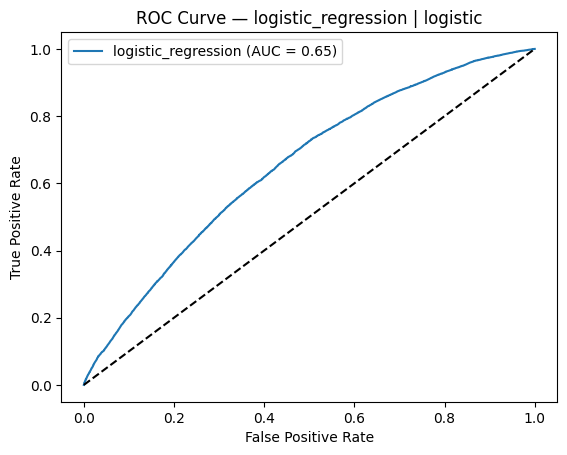

Saved: outputs/stage1_results/roc_curves/logistic_regression_logistic.png


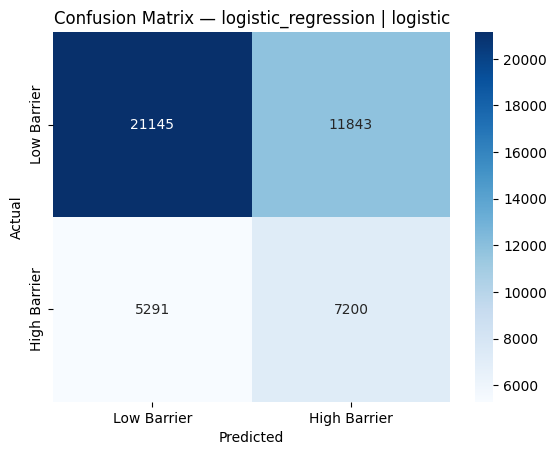

Saved: outputs/stage1_results/confusion_matrices/logistic_regression_logistic.png


In [7]:
# If running in a fresh kernel, run Cell 5 first to define model/X_test/y_test and src path.
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix

plot_roc_curve(model, X_test, y_test, "logistic_regression", "logistic")
plot_confusion_matrix(model, X_test, y_test, "logistic_regression", "logistic")

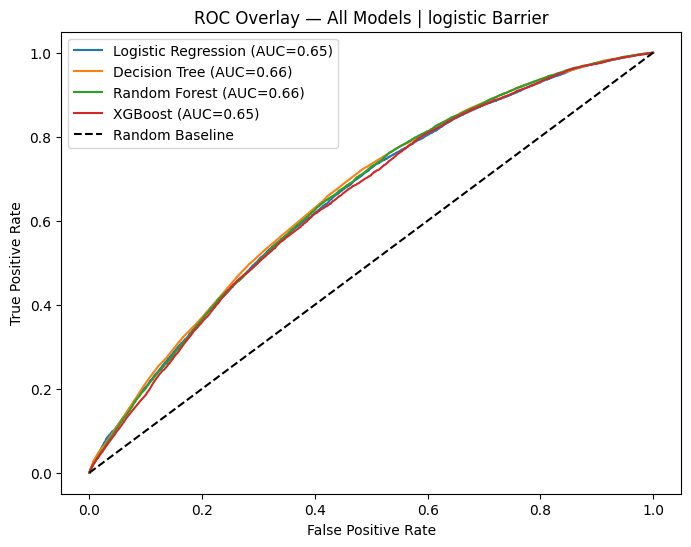

Saved: outputs/stage1_results/roc_curves/overlay_logistic.png


In [8]:
# If running in a fresh kernel, run Cell 5 first to define PROJECT_ROOT/X_test/y_test and src path.
from src.evaluation.visualise import plot_roc_overlay

import joblib

lr_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'logistic_regression_logistic.pkl')
dt_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'decision_tree_logistic.pkl')
rf_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'random_forest_logistic.pkl')
xgb_model = joblib.load(PROJECT_ROOT / 'saved_models' / 'stage1' / 'xgboost_logistic.pkl')

plot_roc_overlay(
    {
        "Logistic Regression": lr_model,
        "Decision Tree": dt_model,
        "Random Forest": rf_model,
        "XGBoost": xgb_model,
    },
    X_test, y_test, "logistic"
)

In [9]:
out_dir = PROJECT_ROOT / 'outputs' / 'stage1_results'
out_dir.mkdir(parents=True, exist_ok=True)

results_path = out_dir / 'logistic_results.csv'
results_df.to_csv(results_path, index=False)
print('Saved results to:', results_path)

Saved results to: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\outputs\stage1_results\logistic_results.csv
